导入库与定义函数

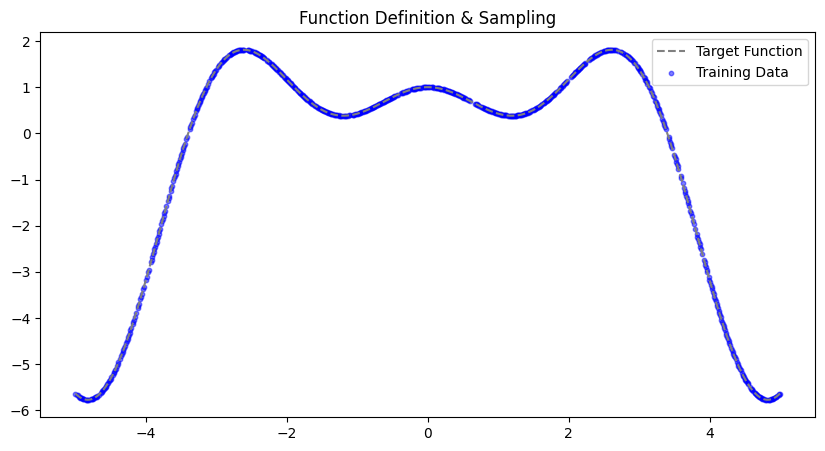

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义被拟合的复合函数
def target_function(x):
    return x * np.sin(x) + np.cos(2*x)

# 2. 生成数据
np.random.seed(42)
x_data = np.linspace(-5, 5, 1000).reshape(-1, 1) # 采样1000个点
y_data = target_function(x_data)

# 划分训练集和测试集 (80% 训练, 20% 测试)
indices = np.random.permutation(len(x_data))
train_idx, test_idx = indices[:800], indices[800:]
x_train, y_train = x_data[train_idx], y_data[train_idx]
x_test, y_test = x_data[test_idx], y_data[test_idx]

# 可视化原始函数
plt.figure(figsize=(10, 5))
plt.plot(x_data, y_data, label='Target Function', color='gray', linestyle='--')
plt.scatter(x_train, y_train, color='blue', s=10, alpha=0.5, label='Training Data')
plt.legend()
plt.title("Function Definition & Sampling")
plt.show()

纯 NumPy 构建两层 ReLU 网络

In [6]:
class ReLUNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2./input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2./hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # 动量初始化
        self.vW1, self.vb1 = np.zeros_like(self.W1), np.zeros_like(self.b1)
        self.vW2, self.vb2 = np.zeros_like(self.W2), np.zeros_like(self.b2)
        
    def forward(self, x):
        self.x = x
        self.z1 = np.dot(x, self.W1) + self.b1
        self.a1 = np.maximum(0, self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2
    
    def backward(self, y_pred, y_true, lr, momentum=0.9):
        m = y_true.shape[0]
        dz2 = 2 * (y_pred - y_true) / m
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1.copy()
        dz1[self.z1 <= 0] = 0
        dW1 = np.dot(self.x.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # 梯度裁剪
        for g in [dW1, db1, dW2, db2]:
            np.clip(g, -1.0, 1.0, out=g)

        # 动量更新
        self.vW1 = momentum * self.vW1 - lr * dW1
        self.vb1 = momentum * self.vb1 - lr * db1
        self.vW2 = momentum * self.vW2 - lr * dW2
        self.vb2 = momentum * self.vb2 - lr * db2
        
        self.W1 += self.vW1
        self.b1 += self.vb1
        self.W2 += self.vW2
        self.b2 += self.vb2

训练模型

In [11]:
model = ReLUNetwork(input_size=1, hidden_size=512, output_size=1)
epochs = 20000 # 增加迭代次数，从10000翻倍到20000还是不够
lr = 0.002    # 从0.001调高一点
losses = []

for epoch in range(epochs):
    y_pred = model.forward(x_train)
    loss = np.mean((y_pred - y_train)**2)
    losses.append(loss)
    model.backward(y_pred, y_train, lr)
    
    if epoch % 2000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 9.874191
Epoch 2000, Loss: 0.960813
Epoch 4000, Loss: 1.369663
Epoch 6000, Loss: 0.670751
Epoch 8000, Loss: 0.418130
Epoch 10000, Loss: 0.543273
Epoch 12000, Loss: 0.259316
Epoch 14000, Loss: 0.232244
Epoch 16000, Loss: 0.209778
Epoch 18000, Loss: 0.191592


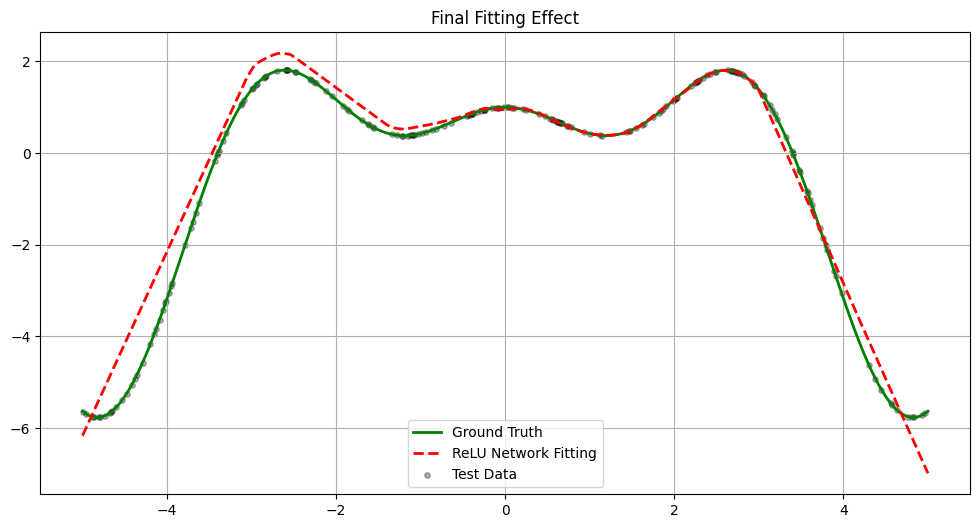

Final Test MSE: 0.1792


In [12]:
# 在测试集上预测
y_test_pred = model.forward(x_test)
# 在全量数据上预测以绘制平滑曲线
y_final_pred = model.forward(x_data)

plt.figure(figsize=(12, 6))
plt.plot(x_data, y_data, 'g-', label='Ground Truth', linewidth=2)
plt.plot(x_data, y_final_pred, 'r--', label='ReLU Network Fitting', linewidth=2)
plt.scatter(x_test, y_test, color='black', s=15, alpha=0.3, label='Test Data')
plt.title("Final Fitting Effect")
plt.legend()
plt.grid(True)
plt.show()

mse_test = np.mean((y_test_pred - y_test)**2)
print(f"Final Test MSE: {mse_test:.4f}")

In [ ]:
model = ReLUNetwork(input_size=1, hidden_size=1024, output_size=1)
epochs = 50000 # 增加迭代次数，从10000翻倍到20000还是不够
lr = 0.002    # 从0.001调高一点
losses = []

for epoch in range(epochs):
    y_pred = model.forward(x_train)
    loss = np.mean((y_pred - y_train)**2)
    losses.append(loss)
    model.backward(y_pred, y_train, lr)
    
    if epoch % 2000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 27.852738
Epoch 2000, Loss: 2.132655
Epoch 4000, Loss: 2.163280
Epoch 6000, Loss: 0.998485
Epoch 8000, Loss: 0.593456
Epoch 10000, Loss: 0.419919
Epoch 12000, Loss: 0.346426
Epoch 14000, Loss: 0.290898
Epoch 16000, Loss: 0.247506
Epoch 18000, Loss: 0.213791
Epoch 20000, Loss: 0.186051
Epoch 22000, Loss: 0.163672
Epoch 24000, Loss: 0.145524
Epoch 26000, Loss: 0.129625
Epoch 28000, Loss: 0.116693
Epoch 30000, Loss: 0.106745
Epoch 32000, Loss: 0.099590
Epoch 34000, Loss: 0.093793
Epoch 36000, Loss: 0.088749
Epoch 38000, Loss: 0.084370
Epoch 40000, Loss: 0.080042
Epoch 42000, Loss: 0.076337
Epoch 44000, Loss: 0.072990
Epoch 46000, Loss: 0.068712
Epoch 48000, Loss: 0.059840


验证效果与可视化结果

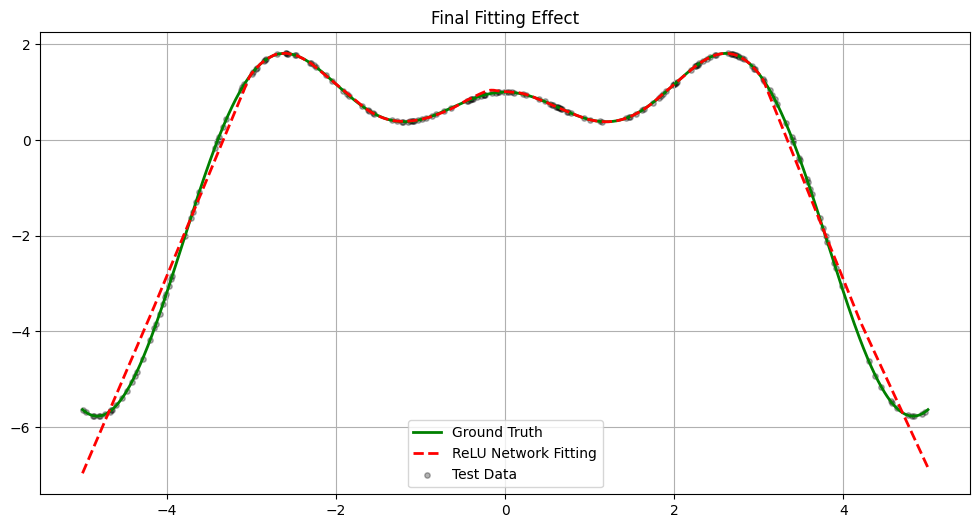

Final Test MSE: 0.0561


In [10]:
# 在测试集上预测
y_test_pred = model.forward(x_test)
# 在全量数据上预测以绘制平滑曲线
y_final_pred = model.forward(x_data)

plt.figure(figsize=(12, 6))
plt.plot(x_data, y_data, 'g-', label='Ground Truth', linewidth=2)
plt.plot(x_data, y_final_pred, 'r--', label='ReLU Network Fitting', linewidth=2)
plt.scatter(x_test, y_test, color='black', s=15, alpha=0.3, label='Test Data')
plt.title("Final Fitting Effect")
plt.legend()
plt.grid(True)
plt.show()

mse_test = np.mean((y_test_pred - y_test)**2)
print(f"Final Test MSE: {mse_test:.4f}")